In [1]:
import pandas as pd
import numpy as np
import anndata as ad
from intervaltree import IntervalTree
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties

path = f"{indir}/arial.ttf"
fontManager.addfont(path)
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 5

prop = FontProperties(fname=path)
sns.reset_defaults()
sns.set(context=None,
    style=None,
    palette=None,
    font=prop.get_name(),
    font_scale=None,
    color_codes=None,
    rc=None,)

the_padding=0.6
red_alpha=0.7
hist_width=44
the_upper_ylim=1.075
bar_width=0.55
errorbar_setting={"ecolor":"black","elinewidth":0.6,"capsize":2.5,"capthick":0.6,"fmt":"none"}

In [ ]:
stats_path="../../../../04.data/05.intermediate_files/02.DNA/01.Young_Mouse/number_statstics_for_DMRs.xlsx"

In [4]:
sheet_names=pd.ExcelFile(stats_path).sheet_names

In [5]:
def e_formatter(tick):
    the_number=str(int(tick))
    if the_number=="0":
        return "0"
    number_of_0s=0
    while the_number[-1]=="0":
        number_of_0s +=1
        the_number=the_number[:-1]
    return the_number+"e"+str(number_of_0s)
e_formatter(134050000.0)

'13405e4'

01_threeclass
02_subclasses_in_neuron
03_subclasses_in_NN


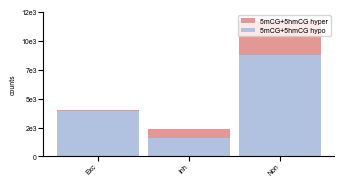

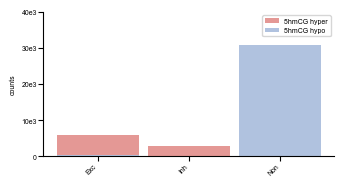

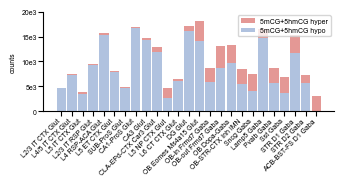

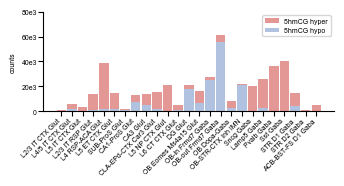

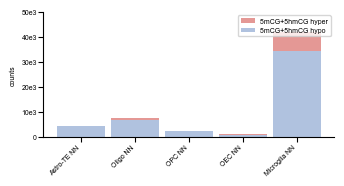

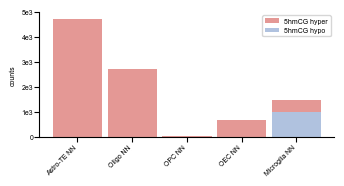

In [ ]:
for sheet_name_ in sheet_names:
    print(sheet_name_)
    stats=pd.read_excel(stats_path, sheet_name=sheet_name_, index_col=0)
    for modification_ in ["5mCG", "5hmCG"]:
        stats2=stats.loc[stats.index!="total",
            stats.columns.str.startswith(modification_) &\
            ~(stats.columns.str.endswith("total"))]       
        
        fig, ax = plt.subplots(figsize=(90/25.4,50/25.4))
        bottom = np.zeros(stats2.shape[0])
        for type_, counts_ in stats2[stats2.columns[::-1]].to_dict().items():
            p = ax.bar(counts_.keys(), counts_.values(), width=0.9,
                       label=(("5mCG+5hmCG" if type_.split(" ")[0]=="5mCG" else "5hmCG")+\
                              " "+type_.split(" ")[1]),
                       color=("#E49895" if type_.split(" ")[1]=="hyper" else "#B0C2DF"),
                       bottom=bottom)
            bottom += np.array(list(counts_.values()), dtype=np.float64)


        #get handles and labels
        handles, labels = ax.get_legend_handles_labels()

        #specify order of items in legend
        order = [1, 0]

        #add legend to plot
        ax.legend([handles[idx] for idx in order],
          [labels[idx] for idx in order],
          loc="upper right", fontsize=5)
        ax.set_xticks(ticks=ax.get_xticks(),
                      labels=ax.get_xticklabels(),
                      rotation=45,
                      horizontalalignment='right',
                      verticalalignment='top',
                     fontsize=5
                     )
        ax.set_yticks(ticks=ax.get_yticks(),
                      labels=[(str(int(tick))[:-3]+"e3" if tick!=0 else "0") for tick in ax.get_yticks()],
                      fontsize=5)
        ax.tick_params(pad=1)
        ax.set_ylabel("counts", fontsize=5)

        ax.spines['right'].set_visible(False)  # 设置右边边框不可见
        ax.spines['top'].set_visible(False)  # 设置顶部边框不可见
        plt.tight_layout()
        #plt.show()
        plt.savefig(f"../../../../output/01.Young_Mouse/02-summarize_RankSumTest/03-stacked_barplot_for_DMR_number/{sheet_name_}-{modification_}-DMR_number_plot.pdf")
        plt.savefig(f"../../../../output/01.Young_Mouse/02-summarize_RankSumTest/03-stacked_barplot_for_DMR_number/{sheet_name_}-{modification_}-DMR_number_plot.png", dpi=600)

In [39]:
stats2

,5mCG hyper,5mCG hypo
Astro-TE NN,1820,18492
Oligo NN,3069,24210
OPC NN,787,9980
OEC NN,2890,6848
Microglia NN,45943,70834


In [28]:
sheet_name_=sheet_names[1]

In [29]:
stats=pd.read_excel(stats_path, sheet_name=sheet_name_, index_col=0)

In [32]:
stats2=stats[stats.index!="total"]

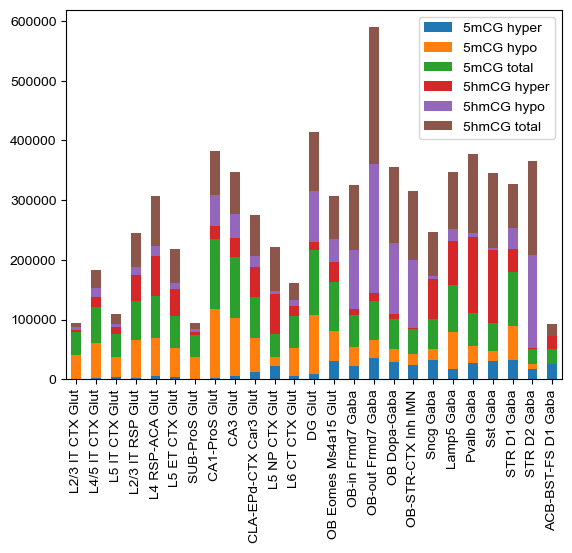

In [33]:
stats2.plot(kind="bar", stacked=True)
plt.show()

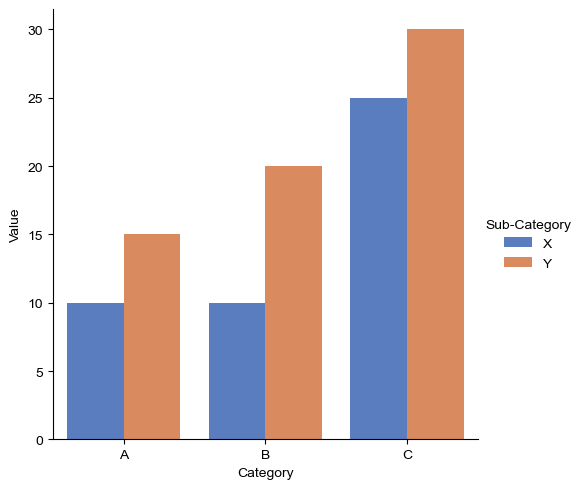

In [20]:
df = pd.DataFrame({
    'Category': ['A', 'A', 'B', 'B', 'C', 'C'],
    'Sub-Category': ['X', 'Y', 'X', 'Y', 'X', 'Y'],
    'Value': [10, 15, 10, 20, 25, 30]
})
sns.catplot(x="Category", y="Value", hue="Sub-Category", kind="bar", data=df, palette="muted")